# Experimental Analysis: eALS for Implicit Feedback Recommendation

This notebook evaluates the **element-wise ALS (eALS)** algorithm on the MovieLens dataset.

**Experiments:**
1. **Convergence** — Loss and recommendation quality vs. iteration count
2. **Impact of latent factors (k)** — How dimensionality affects quality and speed
3. **Scalability by dataset size** — Subsampling users at 25%, 50%, 75%, 100%
4. **NumPy vs. PySpark RDD** — Overhead/benefit comparison
5. **Baseline comparison** — eALS vs. Spark MLlib ALS

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

from data_loader import load_and_prepare
from eals_numpy import eals_train
from evaluation import evaluate_multiple_k

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

# Paths
DATA_DIR = os.path.join(os.getcwd(), "..", "data")
FIG_DIR = os.path.join(os.getcwd(), "..", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Reproducibility
SEED = 42

print("Setup complete.")

Setup complete.


In [2]:
# Load full dataset
data = load_and_prepare(DATA_DIR, dataset="100k", min_user_interactions=5)

print(f"\nDataset summary:")
print(f"  Users:  {data['num_users']}")
print(f"  Items:  {data['num_items']}")
print(f"  Train:  {data['train_matrix'].nnz} interactions")
print(f"  Test:   {len(data['test_dict'])} users")
print(f"  Density: {data['train_matrix'].nnz / (data['num_users'] * data['num_items']) * 100:.2f}%")

Loaded 100000 raw interactions from MovieLens 100k
Re-indexed: 943 users, 1682 items
Binarized: 100000 positive interactions (threshold=0.0)
Filtered: 943 users (min=5), 1682 items (min=0), 100000 interactions remaining


Re-indexed: 943 users, 1682 items
Interaction matrix: 943x1682, 100000 non-zeros, density=6.3047%


Train/test split: 99057 train interactions, 943 test users

Dataset summary:
  Users:  943
  Items:  1682
  Train:  99057 interactions
  Test:   943 users
  Density: 6.25%


## Experiment 1: Convergence Analysis

Train eALS for 50 iterations and track both loss and recommendation quality over time. This shows how quickly the algorithm converges and whether more iterations yield diminishing returns.

In [3]:
from eals_numpy import _update_users, _update_items, _compute_loss

NUM_ITER_CONV = 50
K_CONV = 32

# Evaluate metrics at iterations 1-5, then every 5 iterations
eval_every = 5
eval_at = set(list(range(1, 6)) + list(range(eval_every, NUM_ITER_CONV + 1, eval_every)))

M, N = data["train_matrix"].shape
R_csr = data["train_matrix"].tocsr()
R_csc = data["train_matrix"].tocsc()
c_obs = 2.0  # 1 + alpha
c0 = 1.0
reg = 0.01

rng = np.random.RandomState(SEED)
P = rng.normal(0, 0.01, (M, K_CONV))
Q = rng.normal(0, 0.01, (N, K_CONV))

conv_results = []
print(f"Training eALS (k={K_CONV}) for {NUM_ITER_CONV} iterations...")

for it in range(1, NUM_ITER_CONV + 1):
    t0 = time.time()

    Sq = Q.T @ Q
    _update_users(P, Q, R_csr, Sq, c_obs, c0, reg, M, K_CONV)
    Sp = P.T @ P
    _update_items(P, Q, R_csc, Sp, c_obs, c0, reg, N, K_CONV)

    elapsed = time.time() - t0
    loss = _compute_loss(P, Q, R_csr, c_obs, c0, reg, M)

    row = {"iteration": it, "loss": loss, "time_s": elapsed}

    if it in eval_at:
        metrics = evaluate_multiple_k(P, Q, data["train_matrix"], data["test_dict"], k_values=(5, 10, 20))
        row.update(metrics)
        print(f"  Iter {it:3d} | loss={loss:.1f} | HR@10={metrics['HR@10']:.4f} | "
              f"NDCG@10={metrics['NDCG@10']:.4f} | {elapsed:.2f}s")
    else:
        print(f"  Iter {it:3d} | loss={loss:.1f} | {elapsed:.2f}s")

    conv_results.append(row)

conv_df = pd.DataFrame(conv_results)
print("\nConvergence training complete.")

Training eALS (k=32) for 50 iterations...


  Iter   1 | loss=124032.9 | HR@10=0.0700 | NDCG@10=0.0387 | 0.87s


  Iter   2 | loss=107661.6 | HR@10=0.1177 | NDCG@10=0.0636 | 0.78s


  Iter   3 | loss=104921.1 | HR@10=0.1432 | NDCG@10=0.0738 | 0.78s


  Iter   4 | loss=103636.4 | HR@10=0.1548 | NDCG@10=0.0784 | 0.78s


...

  Iter  46 | loss=100941.6 | 0.82s


  Iter  47 | loss=100938.2 | 0.81s


  Iter  48 | loss=100935.0 | 0.80s


  Iter  49 | loss=100931.9 | 0.85s


  Iter  50 | loss=100928.9 | HR@10=0.1516 | NDCG@10=0.0754 | 0.82s

Convergence training complete.


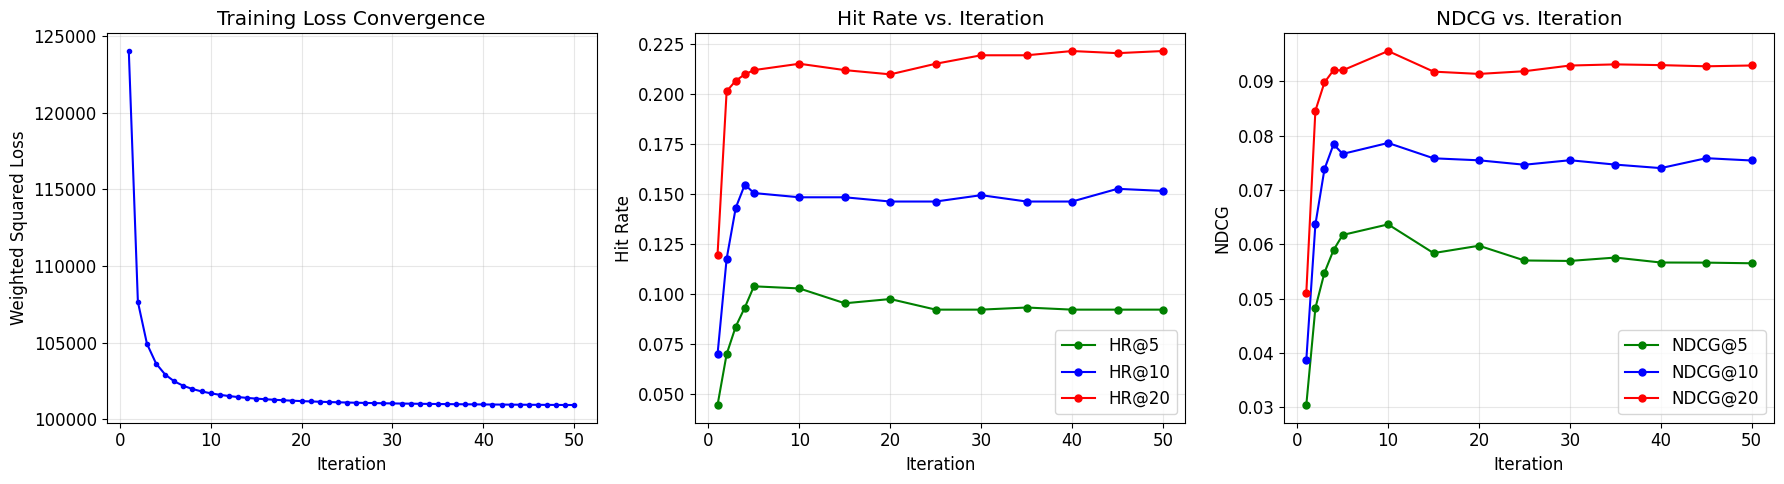

Figure saved to /Users/mdiaspinto/Documents/School/Winter 2026/Data Management/Project/notebooks/../figures/convergence.png


In [4]:
# Plot convergence: loss and metrics over iterations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(conv_df["iteration"], conv_df["loss"], "b-o", markersize=3)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Weighted Squared Loss")
axes[0].set_title("Training Loss Convergence")

# HR@K curves
eval_df = conv_df.dropna(subset=["HR@10"])
for k_val, color in [(5, "green"), (10, "blue"), (20, "red")]:
    col = f"HR@{k_val}"
    axes[1].plot(eval_df["iteration"], eval_df[col], f"-o", color=color,
                 markersize=5, label=f"HR@{k_val}")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Hit Rate")
axes[1].set_title("Hit Rate vs. Iteration")
axes[1].legend()

# NDCG@K curves
for k_val, color in [(5, "green"), (10, "blue"), (20, "red")]:
    col = f"NDCG@{k_val}"
    axes[2].plot(eval_df["iteration"], eval_df[col], f"-o", color=color,
                 markersize=5, label=f"NDCG@{k_val}")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("NDCG")
axes[2].set_title("NDCG vs. Iteration")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "convergence.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {FIG_DIR}/convergence.png")

## Experiment 2: Impact of Latent Factors (k)

Varying k controls the expressiveness of the model. Larger k can capture more nuanced preferences but increases computation cost (O(|R|k + (M+N)k²)) and risk of overfitting.

In [5]:
K_VALUES = [8, 16, 32, 64]
NUM_ITER_K = 30

k_results = []

for k in K_VALUES:
    print(f"\n--- k = {k} ---")
    t0 = time.time()
    P_k, Q_k, losses_k = eals_train(
        data["train_matrix"], num_factors=k, num_iter=NUM_ITER_K,
        reg=0.01, alpha=1.0, c0=1.0, seed=SEED, verbose=False
    )
    total_time = time.time() - t0
    avg_time = total_time / NUM_ITER_K

    metrics = evaluate_multiple_k(P_k, Q_k, data["train_matrix"], data["test_dict"], k_values=(5, 10, 20))

    row = {
        "k": k,
        "final_loss": losses_k[-1] if losses_k else None,
        "total_time_s": total_time,
        "avg_iter_time_s": avg_time,
    }
    row.update(metrics)
    k_results.append(row)

    print(f"  HR@10={metrics['HR@10']:.4f} | NDCG@10={metrics['NDCG@10']:.4f} | "
          f"avg iter={avg_time:.2f}s | total={total_time:.1f}s")

k_df = pd.DataFrame(k_results)
print("\n")
print(k_df.to_string(index=False))


--- k = 8 ---


  HR@10=0.1209 | NDCG@10=0.0564 | avg iter=0.32s | total=9.6s

--- k = 16 ---


  HR@10=0.1453 | NDCG@10=0.0731 | avg iter=0.62s | total=18.6s

--- k = 32 ---


  HR@10=0.1495 | NDCG@10=0.0755 | avg iter=0.84s | total=25.3s

--- k = 64 ---


  HR@10=0.1485 | NDCG@10=0.0739 | avg iter=1.54s | total=46.1s


 k    final_loss  total_time_s  avg_iter_time_s     HR@5    HR@10    HR@20   NDCG@5  NDCG@10  NDCG@20
 8 115545.349780      9.620284         0.320676 0.069989 0.120891 0.191941 0.039977 0.056366 0.074252
16 108782.161063     18.606744         0.620225 0.084836 0.145281 0.211029 0.053369 0.073066 0.089577
32 101033.666894     25.263416         0.842114 0.092259 0.149523 0.219512 0.056920 0.075471 0.092914
64  90531.584878     46.073559         1.535785 0.088017 0.148462 0.218452 0.054355 0.073897 0.091282


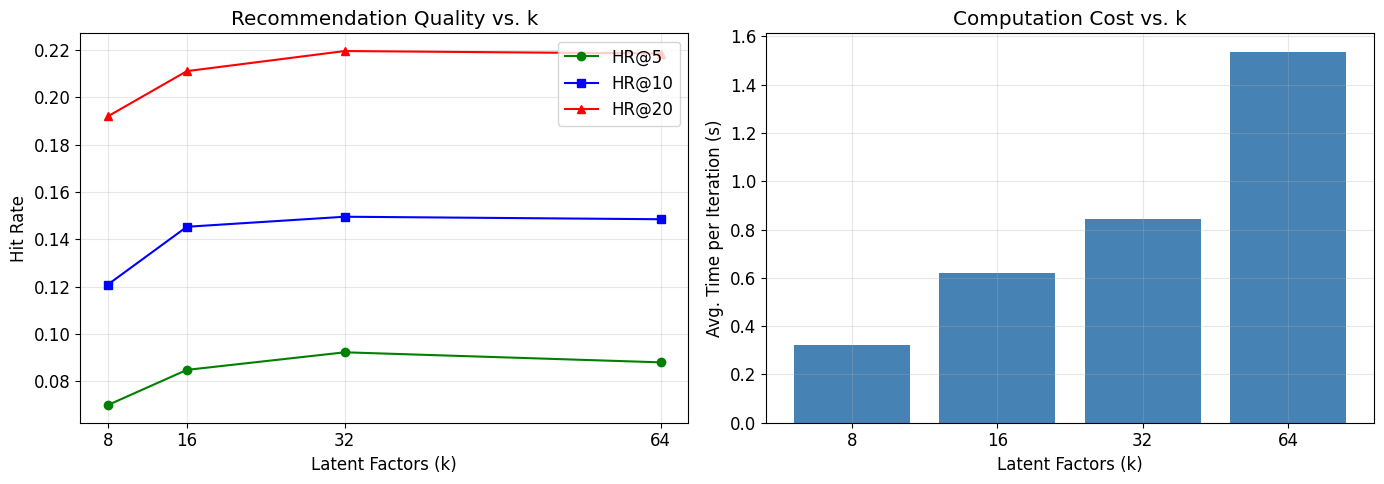

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality vs k
axes[0].plot(k_df["k"], k_df["HR@5"], "g-o", label="HR@5")
axes[0].plot(k_df["k"], k_df["HR@10"], "b-s", label="HR@10")
axes[0].plot(k_df["k"], k_df["HR@20"], "r-^", label="HR@20")
axes[0].set_xlabel("Latent Factors (k)")
axes[0].set_ylabel("Hit Rate")
axes[0].set_title("Recommendation Quality vs. k")
axes[0].set_xticks(K_VALUES)
axes[0].legend()

# Time vs k
axes[1].bar(range(len(K_VALUES)), k_df["avg_iter_time_s"], color="steelblue")
axes[1].set_xticks(range(len(K_VALUES)))
axes[1].set_xticklabels(K_VALUES)
axes[1].set_xlabel("Latent Factors (k)")
axes[1].set_ylabel("Avg. Time per Iteration (s)")
axes[1].set_title("Computation Cost vs. k")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "latent_factors.png"), dpi=150, bbox_inches="tight")
plt.show()

## Experiment 3: Scalability by Dataset Size

Subsample users at different fractions to measure how training time and quality scale with data size. The eALS per-iteration cost is O(|R|k + (M+N)k²), so we expect roughly linear scaling with the number of interactions.

In [7]:
FRACTIONS = [0.25, 0.50, 0.75, 1.0]
NUM_ITER_SCALE = 20
K_SCALE = 32

scale_results = []

for frac in FRACTIONS:
    print(f"\n--- {int(frac*100)}% of users ---")
    data_sub = load_and_prepare(
        DATA_DIR, dataset="100k",
        min_user_interactions=5, subsample_frac=frac
    )

    t0 = time.time()
    P_s, Q_s, losses_s = eals_train(
        data_sub["train_matrix"], num_factors=K_SCALE, num_iter=NUM_ITER_SCALE,
        reg=0.01, alpha=1.0, c0=1.0, seed=SEED, verbose=False
    )
    total_time = time.time() - t0
    avg_time = total_time / NUM_ITER_SCALE

    metrics = evaluate_multiple_k(
        P_s, Q_s, data_sub["train_matrix"], data_sub["test_dict"], k_values=(5, 10, 20)
    )

    row = {
        "fraction": frac,
        "num_users": data_sub["num_users"],
        "num_items": data_sub["num_items"],
        "train_nnz": data_sub["train_matrix"].nnz,
        "total_time_s": total_time,
        "avg_iter_time_s": avg_time,
    }
    row.update(metrics)
    scale_results.append(row)

    print(f"  Users={data_sub['num_users']}, Items={data_sub['num_items']}, "
          f"NNZ={data_sub['train_matrix'].nnz}")
    print(f"  HR@10={metrics['HR@10']:.4f} | avg iter={avg_time:.2f}s")

scale_df = pd.DataFrame(scale_results)
print("\n")
print(scale_df[["fraction", "num_users", "num_items", "train_nnz",
                "avg_iter_time_s", "HR@10", "NDCG@10"]].to_string(index=False))


--- 25% of users ---
Loaded 100000 raw interactions from MovieLens 100k
Re-indexed: 943 users, 1682 items
Binarized: 100000 positive interactions (threshold=0.0)


Filtered: 943 users (min=5), 1682 items (min=0), 100000 interactions remaining
Re-indexed: 943 users, 1682 items
Subsampled: kept 235/943 users, 24997/100000 interactions
Re-indexed: 235 users, 1470 items
Interaction matrix: 235x1470, 24997 non-zeros, density=7.2361%
Train/test split: 24762 train interactions, 235 test users


  Users=235, Items=1470, NNZ=24762
  HR@10=0.1277 | avg iter=0.50s

--- 50% of users ---
Loaded 100000 raw interactions from MovieLens 100k
Re-indexed: 943 users, 1682 items
Binarized: 100000 positive interactions (threshold=0.0)
Filtered: 943 users (min=5), 1682 items (min=0), 100000 interactions remaining
Re-indexed: 943 users, 1682 items


Subsampled: kept 471/943 users, 52181/100000 interactions
Re-indexed: 471 users, 1575 items
Interaction matrix: 471x1575, 52181 non-zeros, density=7.0341%
Train/test split: 51710 train interactions, 471 test users


  Users=471, Items=1575, NNZ=51710
  HR@10=0.1380 | avg iter=0.62s

--- 75% of users ---
Loaded 100000 raw interactions from MovieLens 100k
Re-indexed: 943 users, 1682 items
Binarized: 100000 positive interactions (threshold=0.0)
Filtered: 943 users (min=5), 1682 items (min=0), 100000 interactions remaining
Re-indexed: 943 users, 1682 items


Subsampled: kept 707/943 users, 76734/100000 interactions
Re-indexed: 707 users, 1644 items
Interaction matrix: 707x1644, 76734 non-zeros, density=6.6019%
Train/test split: 76027 train interactions, 707 test users


  Users=707, Items=1644, NNZ=76027
  HR@10=0.1485 | avg iter=0.74s

--- 100% of users ---
Loaded 100000 raw interactions from MovieLens 100k
Re-indexed: 943 users, 1682 items
Binarized: 100000 positive interactions (threshold=0.0)
Filtered: 943 users (min=5), 1682 items (min=0), 100000 interactions remaining
Re-indexed: 943 users, 1682 items


Interaction matrix: 943x1682, 100000 non-zeros, density=6.3047%
Train/test split: 99057 train interactions, 943 test users


  Users=943, Items=1682, NNZ=99057
  HR@10=0.1463 | avg iter=0.81s


 fraction  num_users  num_items  train_nnz  avg_iter_time_s    HR@10  NDCG@10
     0.25        235       1470      24762         0.500592 0.127660 0.066407
     0.50        471       1575      51710         0.618293 0.138004 0.071475
     0.75        707       1644      76027         0.736000 0.148515 0.072609
     1.00        943       1682      99057         0.809663 0.146341 0.075457


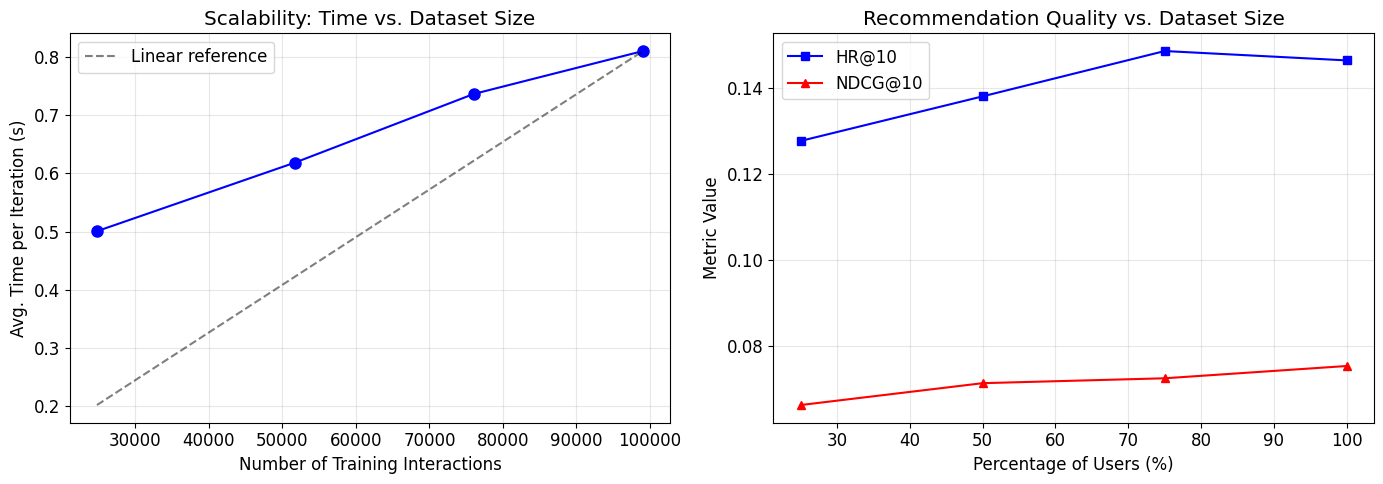

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time vs dataset size
axes[0].plot(scale_df["train_nnz"], scale_df["avg_iter_time_s"], "b-o", markersize=8)
# Overlay linear reference line
x = scale_df["train_nnz"].values
y_linear = x / x[-1] * scale_df["avg_iter_time_s"].values[-1]
axes[0].plot(x, y_linear, "k--", alpha=0.5, label="Linear reference")
axes[0].set_xlabel("Number of Training Interactions")
axes[0].set_ylabel("Avg. Time per Iteration (s)")
axes[0].set_title("Scalability: Time vs. Dataset Size")
axes[0].legend()

# Quality vs dataset size
axes[1].plot(scale_df["fraction"] * 100, scale_df["HR@10"], "b-s", label="HR@10")
axes[1].plot(scale_df["fraction"] * 100, scale_df["NDCG@10"], "r-^", label="NDCG@10")
axes[1].set_xlabel("Percentage of Users (%)")
axes[1].set_ylabel("Metric Value")
axes[1].set_title("Recommendation Quality vs. Dataset Size")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "scalability.png"), dpi=150, bbox_inches="tight")
plt.show()

## Experiment 4: NumPy vs. PySpark RDD

Compare the single-machine NumPy implementation against the distributed PySpark RDD version. On a small dataset (MovieLens 100K), Spark's overhead (JVM startup, serialization, task scheduling) may outweigh the benefit of parallelism. This overhead becomes worthwhile on larger datasets.

In [9]:
from pyspark import SparkContext, SparkConf
from eals_rdd import eals_train_rdd

# Initialize Spark (local mode)
conf = SparkConf().setAppName("eALS-Experiments").setMaster("local[*]")
sc = SparkContext.getOrCreate(conf=conf)
sc.setLogLevel("ERROR")
print(f"Spark initialized: {sc.master}, {sc.defaultParallelism} cores")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/01 16:08:44 WARN Utils: Your hostname, Martins-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.1.1.17 instead (on interface en0)
26/04/01 16:08:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/01 16:08:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark initialized: local[*], 8 cores


In [10]:
NUM_ITER_CMP = 20
K_CMP = 32

impl_results = []

# NumPy run
print("Running NumPy implementation...")
t0 = time.time()
P_np, Q_np, losses_np = eals_train(
    data["train_matrix"], num_factors=K_CMP, num_iter=NUM_ITER_CMP,
    reg=0.01, alpha=1.0, c0=1.0, seed=SEED, verbose=False
)
time_numpy = time.time() - t0
metrics_np = evaluate_multiple_k(P_np, Q_np, data["train_matrix"], data["test_dict"], k_values=(10,))
print(f"  NumPy: {time_numpy:.2f}s total, HR@10={metrics_np['HR@10']:.4f}")

# Spark RDD run
print("Running PySpark RDD implementation...")
t0 = time.time()
P_rdd, Q_rdd, losses_rdd = eals_train_rdd(
    sc, data["train_matrix"], num_factors=K_CMP, num_iter=NUM_ITER_CMP,
    reg=0.01, alpha=1.0, c0=1.0, seed=SEED, verbose=False
)
time_rdd = time.time() - t0
metrics_rdd = evaluate_multiple_k(P_rdd, Q_rdd, data["train_matrix"], data["test_dict"], k_values=(10,))
print(f"  Spark:  {time_rdd:.2f}s total, HR@10={metrics_rdd['HR@10']:.4f}")

impl_results = pd.DataFrame([
    {"Implementation": "NumPy", "Total Time (s)": time_numpy,
     "Avg Iter (s)": time_numpy / NUM_ITER_CMP,
     "Final Loss": losses_np[-1], "HR@10": metrics_np["HR@10"]},
    {"Implementation": "Spark RDD", "Total Time (s)": time_rdd,
     "Avg Iter (s)": time_rdd / NUM_ITER_CMP,
     "Final Loss": losses_rdd[-1], "HR@10": metrics_rdd["HR@10"]},
])

# Verify both implementations produce the same loss (correctness check)
loss_match = np.allclose(losses_np, losses_rdd, rtol=1e-6)
print(f"\nLoss values match: {loss_match}")
print(impl_results.to_string(index=False))

Running NumPy implementation...


  NumPy: 16.35s total, HR@10=0.1463
Running PySpark RDD implementation...


  Spark:  7.35s total, HR@10=0.1463

Loss values match: True
Implementation  Total Time (s)  Avg Iter (s)    Final Loss    HR@10
         NumPy       16.350288      0.817514 101185.616553 0.146341
     Spark RDD        7.351622      0.367581 101185.616553 0.146341


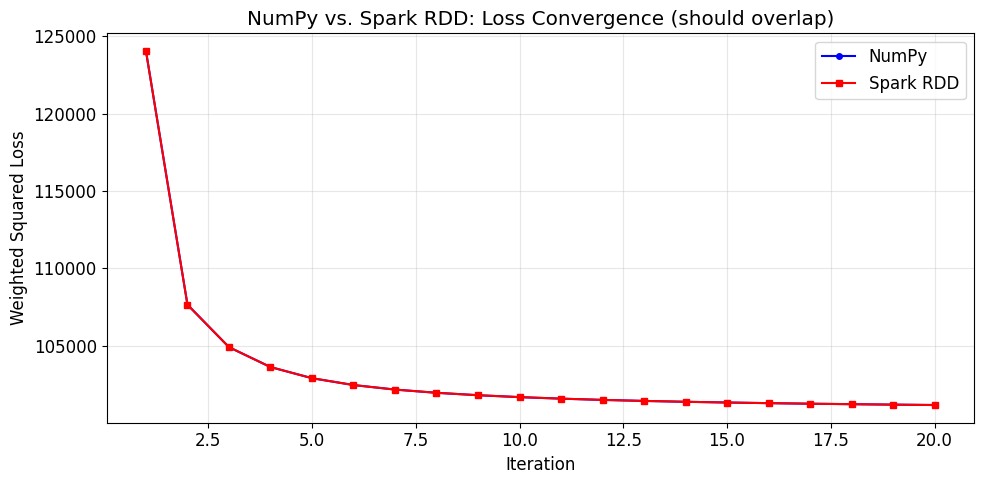

In [11]:
# Per-iteration loss comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, NUM_ITER_CMP + 1), losses_np, "b-o", markersize=4, label="NumPy")
ax.plot(range(1, NUM_ITER_CMP + 1), losses_rdd, "r-s", markersize=4, label="Spark RDD")
ax.set_xlabel("Iteration")
ax.set_ylabel("Weighted Squared Loss")
ax.set_title("NumPy vs. Spark RDD: Loss Convergence (should overlap)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "numpy_vs_spark_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

## Experiment 5: Baseline Comparison — eALS vs. Spark MLlib ALS

Compare our eALS implementation against Spark's built-in ALS (which uses the standard block-wise ALS for implicit feedback). This contextualizes our results against an industry-standard implementation.

In [12]:
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS as MLlibALS

spark = SparkSession.builder.config(conf=sc.getConf()).getOrCreate()

# Prepare training data as a Spark DataFrame: (user, item, rating)
R_csr = data["train_matrix"].tocsr()
train_tuples = []
for u in range(data["num_users"]):
    for i in R_csr[u].indices:
        train_tuples.append((int(u), int(i), 1.0))

train_spark_df = spark.createDataFrame(train_tuples, ["user", "item", "rating"])
train_spark_df.cache()
print(f"Spark DataFrame: {train_spark_df.count()} rows")

Spark DataFrame: 99057 rows


In [13]:
K_BASELINE = 32
NUM_ITER_BASELINE = 20

# Train MLlib ALS (implicit feedback mode)
print("Training Spark MLlib ALS...")
t0 = time.time()
mllib_als = MLlibALS(
    rank=K_BASELINE,
    maxIter=NUM_ITER_BASELINE,
    regParam=0.01,
    alpha=1.0,
    implicitPrefs=True,
    userCol="user",
    itemCol="item",
    ratingCol="rating",
    seed=SEED,
    coldStartStrategy="drop",
)
mllib_model = mllib_als.fit(train_spark_df)
time_mllib = time.time() - t0
print(f"  MLlib ALS trained in {time_mllib:.2f}s")

# Extract factor matrices from MLlib model
user_factors_df = mllib_model.userFactors.collect()
item_factors_df = mllib_model.itemFactors.collect()

P_mllib = np.zeros((data["num_users"], K_BASELINE))
for row in user_factors_df:
    uid = row["id"]
    if uid < data["num_users"]:
        P_mllib[uid] = row["features"]

Q_mllib = np.zeros((data["num_items"], K_BASELINE))
for row in item_factors_df:
    iid = row["id"]
    if iid < data["num_items"]:
        Q_mllib[iid] = row["features"]

# Evaluate MLlib
metrics_mllib = evaluate_multiple_k(
    P_mllib, Q_mllib, data["train_matrix"], data["test_dict"], k_values=(5, 10, 20)
)
print(f"  MLlib: HR@10={metrics_mllib['HR@10']:.4f}, NDCG@10={metrics_mllib['NDCG@10']:.4f}")

Training Spark MLlib ALS...


  MLlib ALS trained in 7.46s


  MLlib: HR@10=0.1538, NDCG@10=0.0786


      Method     HR@5    HR@10    HR@20  NDCG@10
eALS (NumPy) 0.092259 0.149523 0.219512 0.075471
   MLlib ALS 0.097561 0.153765 0.226935 0.078624


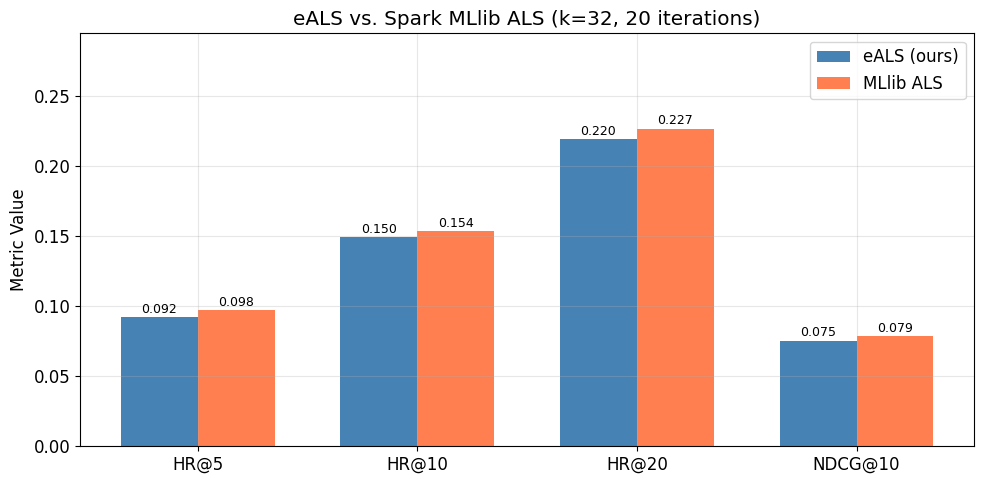

In [14]:
# Compare eALS (NumPy, best from Exp 2) vs MLlib
# Use the k=32 eALS results from Experiment 2
eals_best = k_df[k_df["k"] == K_BASELINE].iloc[0]

comparison = pd.DataFrame([
    {"Method": "eALS (NumPy)", "HR@5": eals_best["HR@5"], "HR@10": eals_best["HR@10"],
     "HR@20": eals_best["HR@20"], "NDCG@10": eals_best["NDCG@10"]},
    {"Method": "MLlib ALS", "HR@5": metrics_mllib["HR@5"], "HR@10": metrics_mllib["HR@10"],
     "HR@20": metrics_mllib["HR@20"], "NDCG@10": metrics_mllib["NDCG@10"]},
])
print(comparison.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
width = 0.35
metrics_labels = ["HR@5", "HR@10", "HR@20", "NDCG@10"]

eals_vals = [comparison.iloc[0][m] for m in metrics_labels]
mllib_vals = [comparison.iloc[1][m] for m in metrics_labels]

bars1 = ax.bar(x - width/2, eals_vals, width, label="eALS (ours)", color="steelblue")
bars2 = ax.bar(x + width/2, mllib_vals, width, label="MLlib ALS", color="coral")

ax.set_ylabel("Metric Value")
ax.set_title("eALS vs. Spark MLlib ALS (k=32, 20 iterations)")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, max(max(eals_vals), max(mllib_vals)) * 1.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eals_vs_mllib.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary of All Results

In [15]:
print("=" * 70)
print("EXPERIMENT 1: CONVERGENCE")
print("=" * 70)
conv_eval = conv_df.dropna(subset=["HR@10"])[["iteration", "loss", "HR@10", "NDCG@10", "time_s"]]
print(conv_eval.to_string(index=False))

print("\n" + "=" * 70)
print("EXPERIMENT 2: LATENT FACTORS")
print("=" * 70)
print(k_df[["k", "HR@5", "HR@10", "HR@20", "NDCG@10", "avg_iter_time_s"]].to_string(index=False))

print("\n" + "=" * 70)
print("EXPERIMENT 3: SCALABILITY")
print("=" * 70)
print(scale_df[["fraction", "num_users", "train_nnz", "avg_iter_time_s", "HR@10"]].to_string(index=False))

print("\n" + "=" * 70)
print("EXPERIMENT 4 & 5: IMPLEMENTATION COMPARISON")
print("=" * 70)
print(impl_results.to_string(index=False))
print()
print(comparison.to_string(index=False))

EXPERIMENT 1: CONVERGENCE
 iteration          loss    HR@10  NDCG@10   time_s
         1 124032.922417 0.069989 0.038666 0.873326
         2 107661.591917 0.117709 0.063636 0.782604
         3 104921.108745 0.143160 0.073838 0.775300
         4 103636.414528 0.154825 0.078414 0.777999
         5 102917.491257 0.150583 0.076638 0.774589
        10 101695.659283 0.148462 0.078652 0.782216
        15 101347.423483 0.148462 0.075828 0.780741
        20 101185.616553 0.146341 0.075457 0.782683
        25 101092.130901 0.146341 0.074642 0.789255
        30 101033.666894 0.149523 0.075471 0.796133
        35 100994.270868 0.146341 0.074665 0.777096
        40 100966.157188 0.146341 0.074021 0.779154
        45 100945.177616 0.152704 0.075848 0.778399
        50 100928.916391 0.151644 0.075422 0.822615

EXPERIMENT 2: LATENT FACTORS
 k     HR@5    HR@10    HR@20  NDCG@10  avg_iter_time_s
 8 0.069989 0.120891 0.191941 0.056366         0.320676
16 0.084836 0.145281 0.211029 0.073066         0.620

In [16]:
# Clean up Spark
try:
    train_spark_df.unpersist()
    sc.stop()
    print("Spark stopped.")
except:
    pass

Spark stopped.
